<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook9_Universal_Program_Induction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 9 — Educational Universal Program Induction

This notebook introduces simplified ideas inspired by Solomonoff induction and
algorithmic probability.

It demonstrates:

- Tiny program enumeration
- Prefix-free intuition
- Universal prior (2^-L)
- Bayesian updating
- Model averaging
- Toy Levin-style search
- Prediction of binary sequences

This is **not** a true implementation of Solomonoff induction, which is
uncomputable because it ranges over all computable programs.


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(1234)
np.random.seed(1234)


In [2]:
class TinyProgram:
    def __init__(self,name,length,fn):
        self.name=name
        self.length=length
        self.fn=fn

    def predict(self,history):
        return self.fn(history)

PROGRAMS=[
TinyProgram("Always0",1,lambda h:0),
TinyProgram("Always1",1,lambda h:1),
TinyProgram("Alternate",2,lambda h:len(h)%2),
TinyProgram("RepeatLast",2,lambda h:h[-1] if h else 0),
TinyProgram("Repeat2Back",3,lambda h:h[-2] if len(h)>1 else 0),
TinyProgram("Majority",3,lambda h:1 if sum(h)>=len(h)/2 else 0),
]


## Universal Prior

In [3]:
weights=np.array([2**(-p.length) for p in PROGRAMS],float)
weights/=weights.sum()

for p,w in zip(PROGRAMS,weights):
    print(f"{p.name:12s} length={p.length} prior={w:.3f}")


Always0      length=1 prior=0.286
Always1      length=1 prior=0.286
Alternate    length=2 prior=0.143
RepeatLast   length=2 prior=0.143
Repeat2Back  length=3 prior=0.071
Majority     length=3 prior=0.071


## Enumerable Search

In [4]:
def enumerate_programs(max_length):
    return [p for p in PROGRAMS if p.length<=max_length]

for L in range(1,4):
    print("Length <=",L,[p.name for p in enumerate_programs(L)])


Length <= 1 ['Always0', 'Always1']
Length <= 2 ['Always0', 'Always1', 'Alternate', 'RepeatLast']
Length <= 3 ['Always0', 'Always1', 'Alternate', 'RepeatLast', 'Repeat2Back', 'Majority']


## Levin-style Cost

In [5]:
def levin_cost(length,runtime):
    return length+math.log2(runtime+1)

for p in PROGRAMS:
    runtime=random.randint(1,20)
    print(p.name,"runtime",runtime,"cost",round(levin_cost(p.length,runtime),2))


Always0 runtime 15 cost 5.0
Always1 runtime 4 cost 3.32
Alternate runtime 1 cost 3.0
RepeatLast runtime 3 cost 4.0
Repeat2Back runtime 19 cost 7.32
Majority runtime 2 cost 4.58


## Bayesian Universal Mixture

In [6]:
class UniversalMixture:
    def __init__(self):
        self.posterior=weights.copy()

    def update(self,history,obs):
        like=[]
        for p in PROGRAMS:
            pred=p.predict(history)
            like.append(0.995 if pred==obs else 0.005)
        like=np.array(like)
        self.posterior*=like
        self.posterior/=self.posterior.sum()

    def predict(self,history):
        p0,p1=0,0
        for w,p in zip(self.posterior,PROGRAMS):
            if p.predict(history)==0:
                p0+=w
            else:
                p1+=w
        return p0,p1


## Learn a Sequence

In [7]:
sequence=[0,1]*30

mix=UniversalMixture()

history=[]
beliefs=[]

for s in sequence:
    p0,p1=mix.predict(history)
    mix.update(history,s)
    beliefs.append(mix.posterior.copy())
    history.append(s)

beliefs=np.array(beliefs)


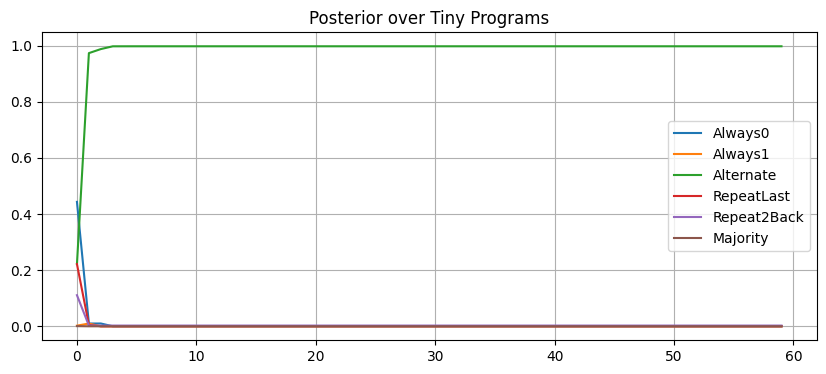

In [8]:
plt.figure(figsize=(10,4))
for i,p in enumerate(PROGRAMS):
    plt.plot(beliefs[:,i],label=p.name)
plt.legend()
plt.grid()
plt.title("Posterior over Tiny Programs")
plt.show()


## Model Averaging

In [9]:
history=[0,1,0,1,0,1]
mix=UniversalMixture()
h=[]
for x in history:
    mix.update(h,x)
    h.append(x)

p0,p1=mix.predict(history)
print("P(next=0) =",round(p0,3))
print("P(next=1) =",round(p1,3))


P(next=0) = 1.0
P(next=1) = 0.0


## Compression Intuition

In [10]:
def description_length(bits):
    changes=1
    for i in range(1,len(bits)):
        if bits[i]!=bits[i-1]:
            changes+=1
    return len(set(bits))+changes

examples=[
[0,0,0,0,0],
[0,1,0,1,0,1],
[1,1,0,1,0,0,1]
]

for e in examples:
    print(e,"approx_DL=",description_length(e))


[0, 0, 0, 0, 0] approx_DL= 2
[0, 1, 0, 1, 0, 1] approx_DL= 8
[1, 1, 0, 1, 0, 0, 1] approx_DL= 7


# Summary

This notebook illustrated:

- Tiny enumerable program spaces
- Universal priors
- Bayesian updating
- Model averaging
- Levin-style search intuition
- Compression and description length

These are educational analogues of the ideas behind Solomonoff induction and
algorithmic probability.

Notebook 10 will integrate:

- Bayesian mixtures
- CTW-inspired prediction
- MCTS planning
- World models
- Unified educational MC-AIXI architecture
- Multiple benchmark environments
